In [1]:
from training.Train_validate import Train_Validate_CNN
from training.Testing_M5_Network_original import Test_model_accuracy_original, Output_Test_Error_Samples
from training.Bcolors import bcolors
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("number of GPUs:", torch.cuda.device_count())
PROJECT_ROOT = Path.cwd().parents[1]
DATASET_DIR = PROJECT_ROOT
MODEL_DIR = PROJECT_ROOT/"models"
FIG_DIR = PROJECT_ROOT/"figs"
print(PROJECT_ROOT)
print(DATASET_DIR)
print(MODEL_DIR)
print(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)
Folder_name_list_of_dataset = ['Synthesized_Dataset/Training_data', 'Synthesized_Dataset/Validate_data', 'Synthesized_Dataset/Testing_data']
Folder_name_list_of_dataset = [DATASET_DIR/i for i in Folder_name_list_of_dataset]

number of GPUs: 4
/home/rkobayashi/anc/GFANC-custom
/home/rkobayashi/anc/GFANC-custom
/home/rkobayashi/anc/GFANC-custom/models
/home/rkobayashi/anc/GFANC-custom/figs


Epoch 1
Learning rate: 0.01
Training Loss: 0.03768837098497897 Training Accuracy: 0.842524999999999
Validation Loss : 0.020101120695471764 Validation Accuracy : 0.898
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_-25.pth
----------------------------------
Epoch 2
Learning rate: 0.01
Training Loss: 0.01722080090083182 Training Accuracy: 0.9153249999999996
Validation Loss : 0.03729026634246111 Validation Accuracy : 0.8505
----------------------------------
Epoch 3
Learning rate: 0.01
Training Loss: 0.016158352331258355 Training Accuracy: 0.9201125000000002
Validation Loss : 0.016724389605224134 Validation Accuracy : 0.921
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_-25.pth
----------------------------------
Epoch 4
Learning rate: 0.01
Training Loss: 0.015600633553694933 Training Accuracy: 0.923300000000001
Validation Loss : 0.016572652105242013 Validation Accuracy : 0.916499999999999

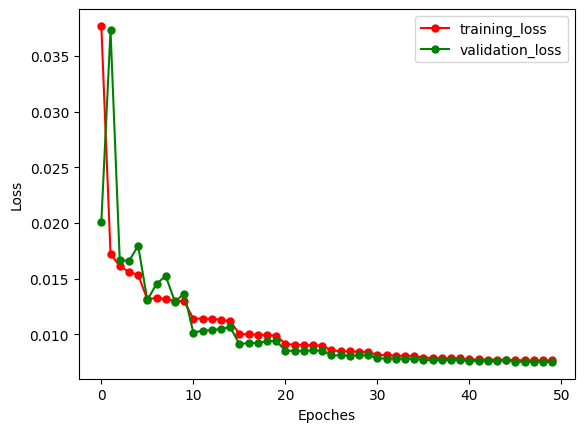

Epoch 1
Learning rate: 0.01
Training Loss: 0.02628461193489784 Training Accuracy: 0.9739625000000047
Validation Loss : 0.0021359185338951647 Validation Accuracy : 0.9925
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_0.pth
----------------------------------
Epoch 2
Learning rate: 0.01
Training Loss: 0.0043031114782206715 Training Accuracy: 0.9905250000000048
Validation Loss : 0.002833684196230024 Validation Accuracy : 0.9900000000000002
----------------------------------
Epoch 3
Learning rate: 0.01
Training Loss: 0.003960243587316654 Training Accuracy: 0.9909625000000045
Validation Loss : 0.0019760162467719056 Validation Accuracy : 0.9925
----------------------------------
Epoch 4
Learning rate: 0.01
Training Loss: 0.0038614042292465455 Training Accuracy: 0.9911750000000045
Validation Loss : 0.0024359967559576035 Validation Accuracy : 0.9925
----------------------------------
Epoch 5
Learning rate: 0.01
Training Loss: 0.003627850663106

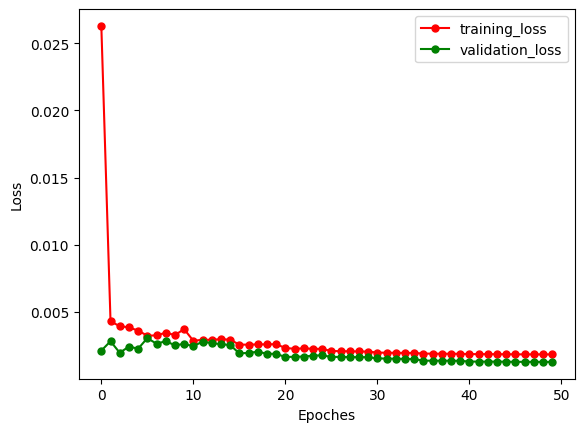

Epoch 1
Learning rate: 0.01
Training Loss: 0.20077716978266835 Training Accuracy: 0.4499249999999997
Validation Loss : 0.12834845781326293 Validation Accuracy : 0.49449999999999994
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_5.pth
----------------------------------
Epoch 2
Learning rate: 0.01
Training Loss: 0.09996422860771417 Training Accuracy: 0.5764375000000005
Validation Loss : 0.10667861551046372 Validation Accuracy : 0.546
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_5.pth
----------------------------------
Epoch 3
Learning rate: 0.01
Training Loss: 0.09432100644335151 Training Accuracy: 0.5933875
Validation Loss : 0.0991164967417717 Validation Accuracy : 0.5615
Trained feed forward net saved at /home/rkobayashi/anc/GFANC-custom/models/M6_res_Synthetic_delay_5.pth
----------------------------------
Epoch 4
Learning rate: 0.01
Training Loss: 0.09174282278865575 Training Accur

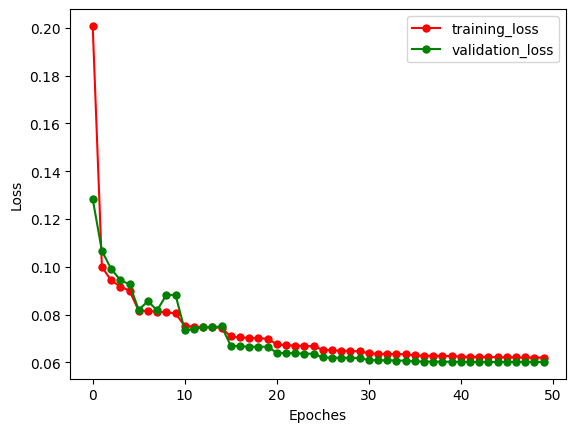

In [2]:
delays = [-25, 0, 5]
for delay in delays:
    File_sheet = "Hard_Index_delay_" + str(delay) + ".csv"
    model_name = "M6_res_Synthetic_delay_" + str(delay) + ".pth"
    MODEL_PTH = MODEL_DIR/model_name
    figure_name = "Training_loss_delay_" + str(delay) + ".png"
    acc_train, acc_validate, train_loss_epochs, validate_loss_epochs = Train_Validate_CNN(TRIAN_DATASET_FILE=Folder_name_list_of_dataset[0]
                                                            , VALIDATION_DATASET_FILE=Folder_name_list_of_dataset[1]
                                                            , MODEL_PTH=MODEL_PTH, File_sheet=File_sheet, BATCH_SIZE=200)
    plt.plot(np.arange(len(train_loss_epochs)),train_loss_epochs, marker='.', markersize=10, color='r',label='training_loss')
    plt.plot(np.arange(len(validate_loss_epochs)),validate_loss_epochs, marker='.', markersize=10, color='g',label='validation_loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoches')
    plt.legend()
    plt.savefig(FIG_DIR/figure_name, dpi=600, bbox_inches='tight', pad_inches=0)
    plt.show()

In [3]:
for delay in delays:
    File_sheet = "Hard_Index_delay_" + str(delay) + ".csv"
    model_name = "M6_res_Synthetic_delay_" + str(delay) + ".pth"
    MODEL_PTH = MODEL_DIR/model_name
    # Output the test error samples by the pre-trained network
    if os.path.exists(MODEL_PTH):
        acc = Output_Test_Error_Samples(TESTING_DATASET_FILE=Folder_name_list_of_dataset[2]
                                        , MODLE_PTH=MODEL_PTH, File_sheet=File_sheet)
        repot = bcolors.OKGREEN  + f' The accuracy on testing datast is {acc}' + bcolors.ENDC
        print(repot)
    else:
        print(bcolors.FAIL + MODEL_PTH + ' does not exsit !' + bcolors.ENDC)

length of testing_dataset:2000
105_Frequency_from_7741_to_7892_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
330_Frequency_from_2132_to_6406_Hz.wav [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0] [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
1639_Frequency_from_7975_to_7979_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0] [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]
297_Frequency_from_4243_to_7540_Hz.wav [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
66_Frequency_from_3174_to_6015_Hz.wav [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0] [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0]
1473_Frequency_from_6890_to_7319_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
1719_Frequency_from_7968_to_7971_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
412_Frequency_from_7894_to_7921_Hz.wav [0, 0, 0, 0